In [1]:
## Import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED = Path("../data/processed")
RAW = Path("../data/raw")

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.1f}".format)

## Load data

In [2]:
inventory_daily = pd.read_csv(PROCESSED / "inventory_daily.csv", parse_dates=["date"])
movements       = pd.read_csv(RAW / "inventory_movements.csv", parse_dates=["timestamp"])
products        = pd.read_csv(RAW / "products.csv")

# Fokus ke produk yang dijual saja (exclude bahan baku & kemasan)
produk_dijual = products[products["item_type"] == "PRODUK_DIJUAL"][["id", "name", "stock"]]
produk_dijual = produk_dijual.rename(columns={"id": "product_id", "stock": "current_stock"})

print(inventory_daily.shape, movements.shape, produk_dijual.shape)

(1005, 6) (2270, 8) (11, 3)


## 1. Total unit terjual per produk (dari movements, reason='sale')

In [3]:
sales_movements = movements[movements["reason"] == "sale"].copy()
sales_movements["qty_sold"] = -sales_movements["quantity_change"]  # sale = negatif, balikkan jadi positif

total_sold = (
    sales_movements.groupby("product_id")["qty_sold"]
    .sum()
    .reset_index()
)

n_days = (inventory_daily["date"].max() - inventory_daily["date"].min()).days + 1
total_sold["avg_daily_sales"] = total_sold["qty_sold"] / n_days

print(f"Periode data: {n_days} hari")
print(total_sold.sort_values("qty_sold", ascending=False))

Periode data: 120 hari
    product_id  qty_sold  avg_daily_sales
6            7     729.0              6.1
2            3     674.0              5.6
5            6     644.0              5.4
3            4     634.0              5.3
4            5     611.0              5.1
0            1     599.0              5.0
1            2     592.0              4.9
8            9     479.0              4.0
9           10     442.0              3.7
7            8     424.0              3.5
10          11     400.0              3.3


## 2. Rata-rata level stok per produk (untuk turnover)

In [4]:
avg_stock = (
    inventory_daily.groupby("product_id")["stock_akhir"]
    .mean()
    .reset_index()
    .rename(columns={"stock_akhir": "avg_stock_level"})
)

inventory_metrics = (
    produk_dijual
    .merge(total_sold, on="product_id", how="left")
    .merge(avg_stock, on="product_id", how="left")
    .fillna(0)
)

# Inventory turnover (unit terjual / rata-rata stok) — makin tinggi, makin cepat produk berputar
inventory_metrics["turnover"] = (
    inventory_metrics["qty_sold"] / inventory_metrics["avg_stock_level"]
).round(2)

inventory_metrics = inventory_metrics.sort_values("turnover", ascending=False)
print(inventory_metrics[["name", "qty_sold", "avg_stock_level", "turnover"]])

                  name  qty_sold  avg_stock_level  turnover
6              Chitato     729.0             27.4      26.6
8   Rokok Gudang Garam     479.0             20.0      23.9
10      Shampo Pantene     400.0             17.5      22.9
1            Telur 1kg     592.0             27.9      21.2
7      Rokok Sampoerna     424.0             20.2      21.0
0            Beras 5kg     599.0             33.8      17.7
5           Taro Snack     644.0             40.4      15.9
9       Sabun Lifebuoy     442.0             31.2      14.2
4           Aqua 600ml     611.0             51.2      11.9
3       Kopi Kapal Api     634.0             63.7       9.9
2       Indomie Goreng     674.0            134.1       5.0


C:\Users\Tigro\AppData\Local\Temp\ipykernel_27352\4019520964.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inventory_metrics, x="turnover", y="name", ax=ax, palette="Blues_r")


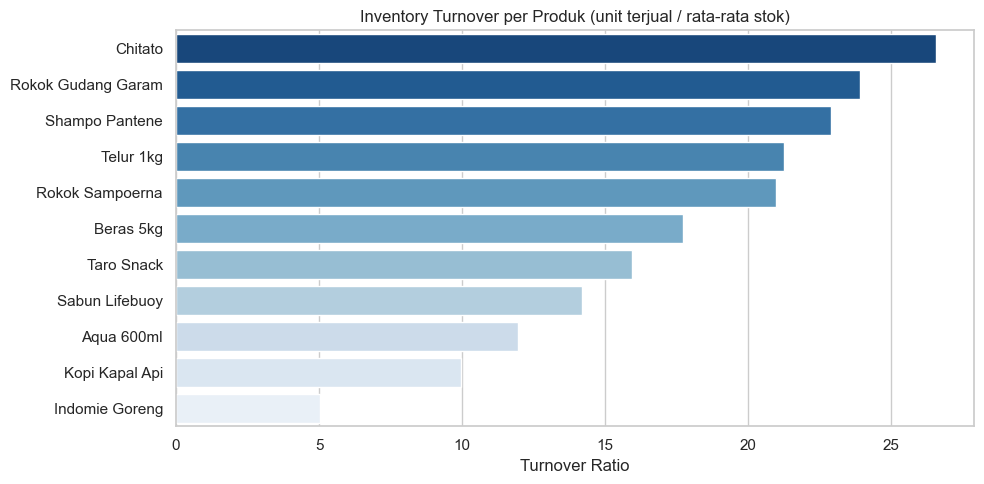

In [5]:
## Visualisasi turnover
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=inventory_metrics, x="turnover", y="name", ax=ax, palette="Blues_r")
ax.set_title("Inventory Turnover per Produk (unit terjual / rata-rata stok)")
ax.set_xlabel("Turnover Ratio")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. Days of Stock Remaining (berdasarkan stok saat ini & rata-rata penjualan harian)

In [6]:
inventory_metrics["days_remaining"] = (
    inventory_metrics["current_stock"] / inventory_metrics["avg_daily_sales"]
).replace([float("inf")], None).round(1)

at_risk = inventory_metrics.sort_values("days_remaining")
print("Produk dengan sisa hari stok tersedikit:")
print(at_risk[["name", "current_stock", "avg_daily_sales", "days_remaining"]].head(10))

Produk dengan sisa hari stok tersedikit:
                  name  current_stock  avg_daily_sales  days_remaining
6              Chitato           15.0              6.1             2.5
9       Sabun Lifebuoy           16.0              3.7             4.3
3       Kopi Kapal Api           26.0              5.3             4.9
7      Rokok Sampoerna           25.0              3.5             7.1
10      Shampo Pantene           24.0              3.3             7.2
8   Rokok Gudang Garam           30.0              4.0             7.5
0            Beras 5kg           39.0              5.0             7.8
1            Telur 1kg           40.0              4.9             8.1
5           Taro Snack           58.0              5.4            10.8
4           Aqua 600ml           69.0              5.1            13.6


C:\Users\Tigro\AppData\Local\Temp\ipykernel_27352\774670425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x="days_remaining", y="name", palette=colors, ax=ax)


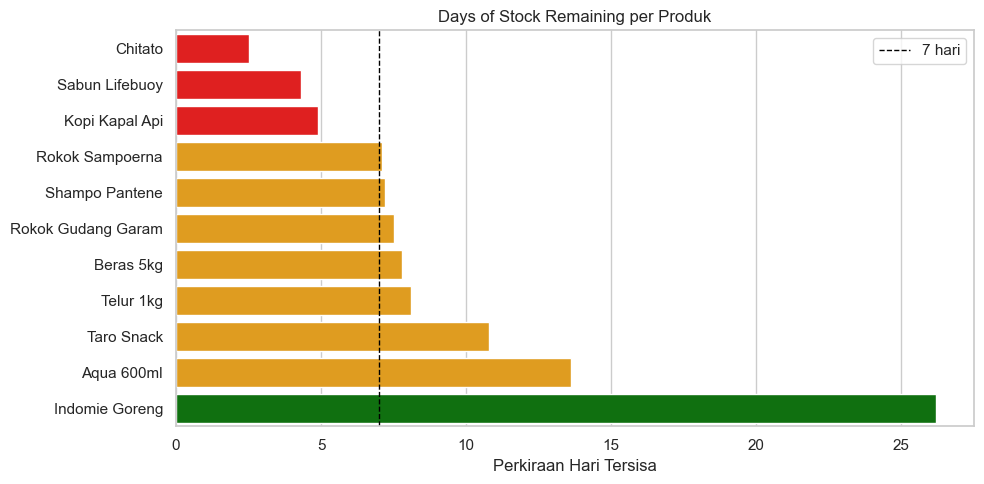

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = inventory_metrics.dropna(subset=["days_remaining"]).sort_values("days_remaining")
colors = ["red" if d < 7 else "orange" if d < 14 else "green" for d in plot_data["days_remaining"]]
sns.barplot(data=plot_data, x="days_remaining", y="name", palette=colors, ax=ax)
ax.axvline(7, color="black", linestyle="--", linewidth=1, label="7 hari")
ax.set_title("Days of Stock Remaining per Produk")
ax.set_xlabel("Perkiraan Hari Tersisa")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Rata-rata interval antar restock (proxy "berapa hari sampai stok kritis")

In [8]:
restocks = movements[movements["reason"] == "restock"].sort_values(["product_id", "timestamp"])
restocks["prev_timestamp"] = restocks.groupby("product_id")["timestamp"].shift(1)
restocks["days_since_prev_restock"] = (
    restocks["timestamp"] - restocks["prev_timestamp"]
).dt.days

avg_restock_interval = (
    restocks.groupby("product_id")["days_since_prev_restock"]
    .mean()
    .reset_index()
    .rename(columns={"days_since_prev_restock": "avg_days_to_critical"})
)

inventory_metrics = inventory_metrics.merge(avg_restock_interval, on="product_id", how="left")
print(inventory_metrics[["name", "avg_days_to_critical"]].sort_values("avg_days_to_critical"))

                  name  avg_days_to_critical
0              Chitato                   5.6
2       Shampo Pantene                   6.3
1   Rokok Gudang Garam                   6.5
3            Telur 1kg                   7.1
4      Rokok Sampoerna                   7.7
5            Beras 5kg                   8.4
6           Taro Snack                   8.9
7       Sabun Lifebuoy                  11.8
8           Aqua 600ml                  12.4
9       Kopi Kapal Api                  14.2
10      Indomie Goreng                  28.0


In [9]:
## Simpan hasil
inventory_metrics_out = inventory_metrics[[
    "product_id", "name", "current_stock", "avg_daily_sales",
    "avg_stock_level", "turnover", "days_remaining", "avg_days_to_critical"
]]
inventory_metrics_out.to_csv(PROCESSED / "inventory_metrics.csv", index=False)
print("Tersimpan ke inventory_metrics.csv")
print(inventory_metrics_out)

Tersimpan ke inventory_metrics.csv
    product_id                name  current_stock  avg_daily_sales  \
0            7             Chitato           15.0              6.1   
1            9  Rokok Gudang Garam           30.0              4.0   
2           11      Shampo Pantene           24.0              3.3   
3            2           Telur 1kg           40.0              4.9   
4            8     Rokok Sampoerna           25.0              3.5   
5            1           Beras 5kg           39.0              5.0   
6            6          Taro Snack           58.0              5.4   
7           10      Sabun Lifebuoy           16.0              3.7   
8            5          Aqua 600ml           69.0              5.1   
9            4      Kopi Kapal Api           26.0              5.3   
10           3      Indomie Goreng          147.0              5.6   

    avg_stock_level  turnover  days_remaining  avg_days_to_critical  
0              27.4      26.6             2.5         